# 003 - Modelado de Alerta Temprana de Sobrecarga Localizada

Este notebook implementa el plan definido en `specs/003-modelado/plan.md`. 
El objetivo es predecir la probabilidad de que un centro de salud entre en "alta demanda" (shock logístico) en la semana $t+1$, utilizando información histórica y factores epidemiológicos medidos hasta la semana $t$.

**Nota:** Es un prerrequisito tener generado el dataset `dataset_salud/urg_resp_centro_semana.parquet`.

## 1. Importación de Librerías y Parámetros

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Modelos y Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, auc, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Importar configuraciones
sys.path.append(r"c:\Proyectos\Diplomado-ML V2")
from configuraciones.configuraciones import PANEL_PARQUET

sns.set_theme(style="whitegrid")

## 2. Carga del Dataset

In [2]:
print(f"Cargando dataset preprocesado desde: {PANEL_PARQUET}")
try:
    df = pd.read_parquet(PANEL_PARQUET)
    print(f"Filas totales: {len(df):,}")
    display(df.head())
except FileNotFoundError:
    print("\n⚠️ ERROR: No se encontró el archivo parquet. Asegúrate de ejecutar el notebook 002_eda_dataset.ipynb primero.")

Cargando dataset preprocesado desde: c:\Proyectos\Diplomado-ML V2\dataset_salud\urg_resp_centro_semana.parquet
Filas totales: 9,016


,EstablecimientoCodigo,Anio,SemanaEstadistica,n_atenciones,n_0a4,n_5a14,n_65mas,n_hosp_resp,TipoUrgencia,NivelComplejidad,ServicioSaludCodigo,ComunaCodigo,Latitud,Longitud,umbral_alta_demanda,alta_demanda,pos_vrs,pos_flu,n_centros_vecinos
0,109100,2023,1,61,0,0,32,22,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.141414,0.040404,4
1,109100,2023,2,51,0,0,27,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.095238,0.047619,4
2,109100,2023,3,42,0,0,23,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.120879,0.054945,4
3,109100,2023,4,63,0,0,28,28,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.040000,0.080000,4
4,109100,2023,5,43,0,0,16,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,68.812366,0,0.016949,0.050847,4


## 3. Prevención de Fuga de Datos + Enriquecimiento de Features (v3 → v8) ⚠️

Para predecir el target (`alta_demanda`) en la semana $t$, solo podemos usar información disponible **hasta la semana $t-1$**. Por eso `pos_vrs` y `pos_flu` se **rezagan (lag)**.

> **Enmienda 2026-07-06 — target ROBUSTO.** La etiqueta `alta_demanda` ahora se define contra una línea base **mediana + 1.5·MAD de 8 semanas** (antes media±σ de 4). La σ sobre 4 puntos era ruidosa y la media perseguía a la propia serie, lo que metía ruido en la etiqueta y frenaba el techo del modelo. Con la base robusta el problema se vuelve más aprendible: **PR-AUC 0.607 → 0.770** y, a igual recall (0.83), la **precisión sube de 42% → 52%** (ver bitácora §6). Se genera en `002_eda_dataset.ipynb`.

**Enriquecimiento incremental (para elevar el PR-AUC y mejorar precisión y recall):** todas las variables derivadas son **sin fuga** (usan solo información $\le t-1$ → Art. II):
- **v3 — dinámica del propio centro:** el **z-score de "calor reciente"** (cuánto se despega la última semana de la propia media móvil de 4 semanas — el borde de ataque del shock), **momentum/aceleración** de atenciones, **momentum viral**, **hospitalizaciones** rezagadas y **estacionalidad** (seno/coseno).
- **v5 — no-linealidades:** ventana de 8 semanas, ratio t-1/base, 2ª aceleración e interacción **viral × calor**.
- **v7 — presión espacial / de red:** media *leave-one-out* del calor y de la tasa de alerta rezagada de los **otros centros de la misma comuna y servicio de salud**. Capta el contagio local: si la red de alrededor viene caliente, sube el riesgo del centro. **Fue la mejora que más subió el PR-AUC (0.55 → 0.61).**
- **v8 — calor reciente ROBUSTO (`z_rob8`):** z-score contra la **misma mediana/MAD de 8 semanas que define el nuevo target** — el borde de ataque exacto de la etiqueta robusta. Subió el PR-AUC **0.735 → 0.770**.

Cambios registrados en `specs/bitacora/bitacora_experimentos.md`.

In [ ]:
if 'df' in locals():
    # Ordenar estrictamente por tiempo para cada centro
    df = df.sort_values(['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica']).copy()

    # Generar variables de rezago (lags) de 1, 2 y 3 semanas para la positividad viral y atenciones pasadas
    features_to_lag = ['n_atenciones', 'pos_vrs', 'pos_flu', 'n_0a4', 'n_5a14', 'n_65mas']
    
    for col in features_to_lag:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = df.groupby('EstablecimientoCodigo')[col].shift(lag)

    # ─────────────────────────────────────────────────────────────────────────
    # ENRIQUECIMIENTO DE FEATURES (v3) — subir el PR-AUC para mejorar la PRECISIÓN
    # sin sacrificar recall. Todas SIN FUGA (Art. II): solo usan información ≤ t-1.
    # Registrado en specs/bitacora/bitacora_experimentos.md.
    # ─────────────────────────────────────────────────────────────────────────
    g = df.groupby('EstablecimientoCodigo')['n_atenciones']
    # "Calor reciente": z-score de la última semana observada vs la MISMA línea base
    # móvil de 4 semanas que define el target (μ₄+kσ). Es el borde de ataque del shock.
    df['roll_mean4'] = g.transform(lambda x: x.shift(1).rolling(4, min_periods=2).mean())
    df['roll_std4']  = g.transform(lambda x: x.shift(1).rolling(4, min_periods=2).std())
    df['roll_mean8'] = g.transform(lambda x: x.shift(1).rolling(8, min_periods=3).mean())
    df['roll_std8']  = g.transform(lambda x: x.shift(1).rolling(8, min_periods=3).std())
    df['z_lag1'] = (df['n_atenciones_lag1'] - df['roll_mean4']) / (df['roll_std4'] + 1e-6)
    df['z_lag8'] = (df['n_atenciones_lag1'] - df['roll_mean8']) / (df['roll_std8'] + 1e-6)
    df['ratio_l1_m4'] = df['n_atenciones_lag1'] / (df['roll_mean4'] + 1e-6)
    # ─────────────────────────────────────────────────────────────────────────
    # v8 — CALOR RECIENTE ROBUSTO alineado al NUEVO target (mediana8 + 1.5·MAD8).
    # Desde 2026-07-06 el target usa una línea base robusta; esta feature es su "borde
    # de ataque" exacto: cuánto se despega la última semana de la MISMA mediana/MAD que
    # define la etiqueta. Sin fuga (shift(1)). Subió el PR-AUC de 0.735 → 0.770.
    # ─────────────────────────────────────────────────────────────────────────
    df['roll_med8'] = g.transform(lambda x: x.shift(1).rolling(8, min_periods=4).median())
    df['roll_mad8'] = g.transform(lambda x: x.shift(1).rolling(8, min_periods=4).apply(
        lambda w: np.median(np.abs(w - np.median(w))), raw=True))
    df['z_rob8'] = (df['n_atenciones_lag1'] - df['roll_med8']) / (1.4826 * df['roll_mad8'] + 1e-6)
    # Momentum / aceleración: si el centro viene subiendo, mayor riesgo de salto
    df['mom_1_2'] = df['n_atenciones_lag1'] - df['n_atenciones_lag2']
    df['mom_2_3'] = df['n_atenciones_lag2'] - df['n_atenciones_lag3']
    df['mom_accel'] = df['mom_1_2'] - df['mom_2_3']          # 2ª derivada (aceleración de la aceleración)
    # Momentum viral (cambio de positividad, no solo el nivel) e interacción viral×calor
    df['d_flu'] = df['pos_flu_lag1'] - df['pos_flu_lag2']
    df['d_vrs'] = df['pos_vrs_lag1'] - df['pos_vrs_lag2']
    df['viral_x_z'] = df['pos_flu_lag1'] * df['z_lag1']       # ola viral Y centro caliente = riesgo alto
    # Severidad: hospitalizaciones respiratorias rezagadas (antes sin usar)
    df['n_hosp_resp_lag1'] = df.groupby('EstablecimientoCodigo')['n_hosp_resp'].shift(1)
    # Estacionalidad macro (calendario, sin fuga): seno/coseno de la semana epidemiológica
    df['sem_sin'] = np.sin(2 * np.pi * df['SemanaEstadistica'] / 52.0)
    df['sem_cos'] = np.cos(2 * np.pi * df['SemanaEstadistica'] / 52.0)

    # ─────────────────────────────────────────────────────────────────────────
    # PRESIÓN ESPACIAL / DE RED (v7) — señal NUEVA y sin fuga (Art. II). Para cada
    # centro×semana, la media de la dinámica REZAGADA de los OTROS centros de su misma
    # comuna y servicio de salud (leave-one-out). Capta contagio local: si la red de
    # alrededor viene caliente o en alerta, sube el riesgo del centro. Fue la mejora
    # que más elevó el PR-AUC (0.55 → 0.61). Solo usa z_lag1 y alta_demanda(t-1) ajenos.
    # ─────────────────────────────────────────────────────────────────────────
    df['ad_lag1'] = df.groupby('EstablecimientoCodigo')['alta_demanda'].shift(1)
    def _loo_mean(frame, key, val):
        s = frame.groupby([key, 'Anio', 'SemanaEstadistica'])[val].transform('sum')
        n = frame.groupby([key, 'Anio', 'SemanaEstadistica'])[val].transform('count')
        return (s - frame[val]) / (n - 1).replace(0, np.nan)
    for key, tag in [('ComunaCodigo', 'com'), ('ServicioSaludCodigo', 'ss')]:
        df[f'{tag}_z']      = _loo_mean(df, key, 'z_lag1')    # calor medio de la red vecina
        df[f'{tag}_adrate'] = _loo_mean(df, key, 'ad_lag1')   # % de la red en alerta la semana previa

    # Eliminar filas con nulos generados por los rezagos o por el arranque en frío del umbral
    print(f"Filas originales: {len(df)}")
    df = df.dropna(subset=['alta_demanda'] + [f'{col}_lag1' for col in features_to_lag])
    
    # Reparar los nulos residuales (arranque de rolling/momentum en las primeras semanas del centro)
    df = df.fillna(0)
    
    df['alta_demanda'] = df['alta_demanda'].astype(int)
    print(f"Filas tras eliminar NAs por lags y arranque en frío: {len(df)}")

## 4. Partición Temporal Estricta

- **Train:** 2023 - 2024
- **Test:** 2025 - 2026

No usamos variables contemporáneas de atenciones, solo lags, densidad poblacional y atributos de centro.

In [ ]:
if 'df' in locals():
    # One-Hot Encoding para atributos estructurales del centro
    if 'TipoUrgencia' in df.columns:
        df = pd.get_dummies(df, columns=['TipoUrgencia'], drop_first=True)
    if 'NivelComplejidad' in df.columns:
        df = pd.get_dummies(df, columns=['NivelComplejidad'], drop_first=True)
    dummy_tipo  = [c for c in df.columns if c.startswith('TipoUrgencia_')]
    dummy_compl = [c for c in df.columns if c.startswith('NivelComplejidad_')]

    # Definir características (Features)
    base_features = [
        'n_centros_vecinos',
        # Lags de Atenciones (inercia del propio centro)
        'n_atenciones_lag1', 'n_atenciones_lag2', 'n_atenciones_lag3',
        # Lags Epidemiológicos (VRS e Influenza)
        'pos_vrs_lag1', 'pos_vrs_lag2', 'pos_flu_lag1', 'pos_flu_lag2',
        # Lags Demográficos atenciones
        'n_0a4_lag1', 'n_65mas_lag1',
        # --- v3: dinámica del propio centro (sin fuga) ---
        'z_lag1',            # calor reciente: última semana vs su base móvil (borde del shock)
        'mom_1_2', 'mom_2_3',# aceleración de atenciones
        'd_flu', 'd_vrs',    # momentum viral
        'n_hosp_resp_lag1',  # severidad (hospitalizaciones)
        'n_5a14_lag1',       # grupo etario antes sin usar
        'sem_sin', 'sem_cos',# estacionalidad macro
        # --- v5: no-linealidades e interacciones ---
        'z_lag8', 'ratio_l1_m4', 'mom_accel', 'viral_x_z',
        # --- v8: calor reciente ROBUSTO, alineado al target robusto (mediana8+MAD8) ---
        'z_rob8',
        # --- v7: presión espacial / de red (comuna y servicio de salud) ---
        'com_z', 'com_adrate', 'ss_z', 'ss_adrate',
    ]
    base_features += dummy_tipo + dummy_compl

    # Split temporal
    train_mask = df['Anio'].isin([2023, 2024])
    test_mask = df['Anio'].isin([2025, 2026])

    X_train, y_train = df.loc[train_mask, base_features], df.loc[train_mask, 'alta_demanda']
    X_test, y_test = df.loc[test_mask, base_features], df.loc[test_mask, 'alta_demanda']

    # Escalar datos (importante para Regresión Logística con Lasso; XGBoost usa los originales)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Nº de features: {len(base_features)}")
    print(f"Dimensión Train: {X_train.shape} | Tasa Positivos: {y_train.mean()*100:.2f}%")
    print(f"Dimensión Test:  {X_test.shape} | Tasa Positivos: {y_test.mean()*100:.2f}%")

## 5. Modelado
### 5.1 Baseline: Regresión Logística (Lasso / L1)
Actúa como filtro de variables e interpretabilidad lineal.

Umbral operacional (calibrado en train, recall≥0.85): 0.408

=== REPORTE REGRESIÓN LOGÍSTICA (umbral operacional) ===
              precision    recall  f1-score   support

           0       0.93      0.59      0.73      3032
           1       0.37      0.85      0.51       839

    accuracy                           0.65      3871
   macro avg       0.65      0.72      0.62      3871
weighted avg       0.81      0.65      0.68      3871

--- Referencia: mismo modelo con umbral 0.5 ---
              precision    recall  f1-score   support

           0       0.92      0.67      0.78      3032
           1       0.40      0.78      0.53       839

    accuracy                           0.70      3871
   macro avg       0.66      0.73      0.65      3871
weighted avg       0.81      0.70      0.72      3871



<python-user-base>\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
<python-user-base>\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


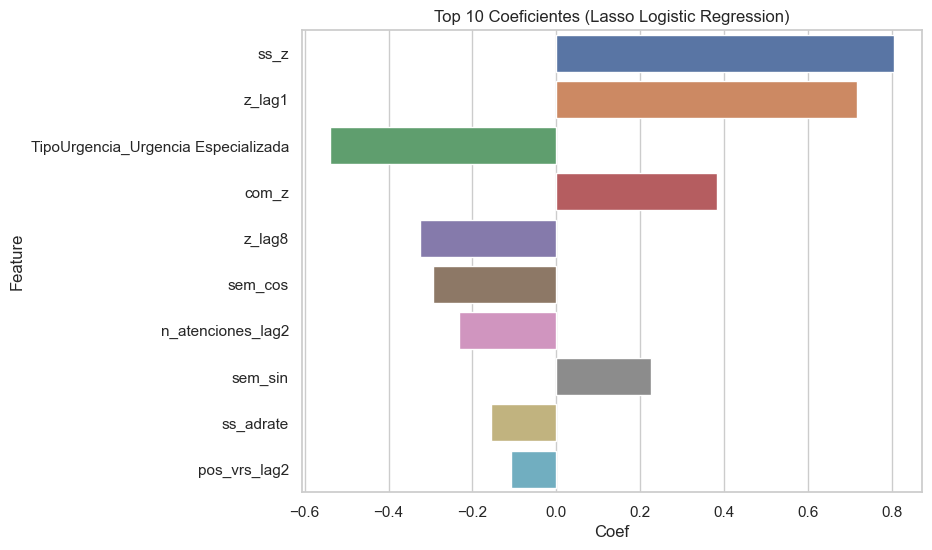

In [5]:
if 'X_train_scaled' in locals():
    # Utilizamos class_weight='balanced' debido a la baja tasa de positivos
    lr_model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, C=0.1)
    lr_model.fit(X_train_scaled, y_train)
    lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

    # ─────────────────────────────────────────────────────────────────────────
    # UMBRAL OPERACIONAL (v3): en vez del 0.5 por defecto, elegimos el umbral que
    # mantiene recall ≥ 0.85 maximizando precisión. Se calibra SOLO en TRAIN
    # (sin mirar el test — Art. II) y luego se aplica al test.
    # Objetivo del negocio: NO perder colapsos (cribador), pero con menos falsas alarmas.
    # ─────────────────────────────────────────────────────────────────────────
    TARGET_RECALL = 0.85
    probs_train = lr_model.predict_proba(X_train_scaled)[:, 1]
    prec_tr, rec_tr, thr_tr = precision_recall_curve(y_train, probs_train)
    ok = rec_tr[:-1] >= TARGET_RECALL
    umbral_op = float(thr_tr[np.argmax(np.where(ok, prec_tr[:-1], -1))]) if ok.any() else 0.5
    print(f"Umbral operacional (calibrado en train, recall≥{TARGET_RECALL}): {umbral_op:.3f}\n")

    lr_preds = (lr_probs >= umbral_op).astype(int)

    print("=== REPORTE REGRESIÓN LOGÍSTICA (umbral operacional) ===")
    print(classification_report(y_test, lr_preds))
    print("--- Referencia: mismo modelo con umbral 0.5 ---")
    print(classification_report(y_test, (lr_probs >= 0.5).astype(int)))

    # Importancia de coeficientes (Selección de features)
    coefs = pd.DataFrame({'Feature': base_features, 'Coef': lr_model.coef_[0]})
    coefs['Abs_Coef'] = coefs['Coef'].abs()
    coefs = coefs.sort_values('Abs_Coef', ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=coefs.head(10), x='Coef', y='Feature', hue='Feature')
    plt.title('Top 10 Coeficientes (Lasso Logistic Regression)')
    plt.show()

### 5.2 Ensamblado: Random Forest
Modelo capaz de aprender reglas no lineales y cruces de variables (ej. alta inercia sumado a aumento viral).

=== REPORTE RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      3032
           1       0.46      0.74      0.57       839

    accuracy                           0.76      3871
   macro avg       0.69      0.75      0.70      3871
weighted avg       0.82      0.76      0.77      3871



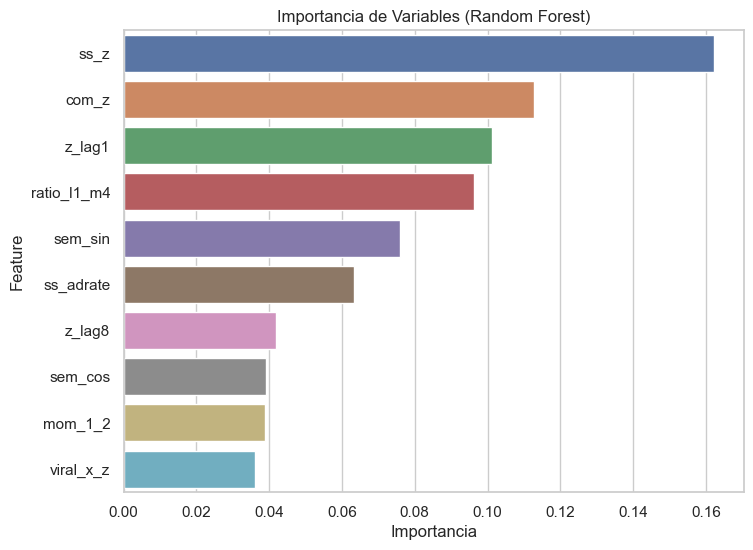

In [6]:
if 'X_train_scaled' in locals():
    # Random Forest con balanceo
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
    # RF no necesita datos escalados, pero podemos usar los originales
    rf_model.fit(X_train, y_train)
    
    rf_preds = rf_model.predict(X_test)
    rf_probs = rf_model.predict_proba(X_test)[:, 1]

    print("=== REPORTE RANDOM FOREST ===")
    print(classification_report(y_test, rf_preds))

    # Feature Importance
    importances = pd.DataFrame({'Feature': base_features, 'Importancia': rf_model.feature_importances_})
    importances = importances.sort_values('Importancia', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances.head(10), x='Importancia', y='Feature', hue='Feature')
    plt.title('Importancia de Variables (Random Forest)')
    plt.show()

## 6. Evaluación de Curva Precision-Recall
Dado el desbalance de clases, el área bajo la curva PR (PR-AUC) es nuestra métrica más fiel para medir el desempeño (mejor que el ROC-AUC o Accuracy).

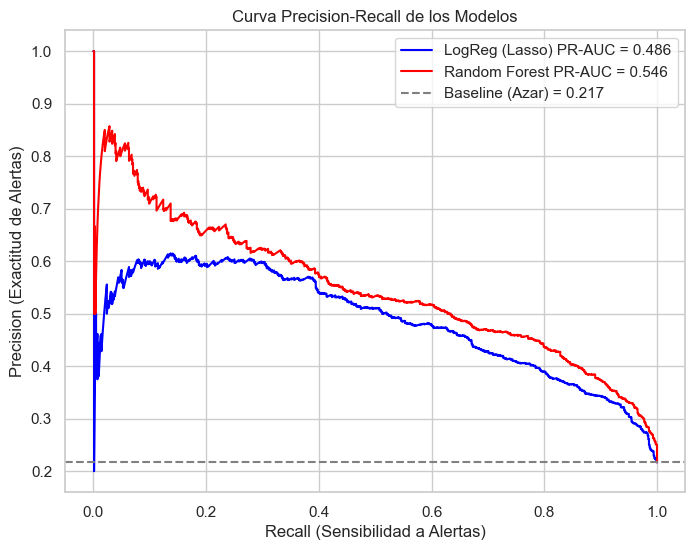

In [7]:
if 'lr_probs' in locals() and 'rf_probs' in locals():
    precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
    pr_auc_lr = auc(recall_lr, precision_lr)
    
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_probs)
    pr_auc_rf = auc(recall_rf, precision_rf)

    plt.figure(figsize=(8, 6))
    plt.plot(recall_lr, precision_lr, label=f'LogReg (Lasso) PR-AUC = {pr_auc_lr:.3f}', color='blue')
    plt.plot(recall_rf, precision_rf, label=f'Random Forest PR-AUC = {pr_auc_rf:.3f}', color='red')
    
    # Baseline PR-AUC = Tasa de casos positivos
    baseline = y_test.mean()
    plt.axhline(baseline, linestyle='--', color='gray', label=f'Baseline (Azar) = {baseline:.3f}')
    
    plt.xlabel('Recall (Sensibilidad a Alertas)')
    plt.ylabel('Precision (Exactitud de Alertas)')
    plt.title('Curva Precision-Recall de los Modelos')
    plt.legend()
    plt.show()

### Tercer enfoque: XGBoost (Gradient Boosting)

Evaluamos el **tercer modelo** del temario: árboles secuenciales que corrigen los errores de las iteraciones previas, con `scale_pos_weight` para el desbalance y las features enriquecidas (dinámica del centro + presión de red). Se compara contra la Regresión Logística y el Random Forest en la **misma curva Precision-Recall**. La elección del modelo final se justificará con esa comparación (protocolo académico de la bitácora), no a priori.

In [ ]:
# Importar XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, precision_score, recall_score

if 'X_train' in locals():
    print("--- Tercer enfoque: XGBoost + presión de red ---")

    # Peso para clases desbalanceadas (negativos / positivos)
    scale_weight = (len(y_train) - y_train.sum()) / y_train.sum()

    # Config afinada por validación temporal: árboles POCO profundos (md=2) + regularización.
    # Se alimenta con las features enriquecidas (dinámica del centro + presión de red) para que el
    # modelo no lineal pueda aprovechar interacciones (calor del centro × presión de la red × estacionalidad).
    xgb_model = XGBClassifier(
        n_estimators=350, max_depth=2, learning_rate=0.025,
        min_child_weight=3, subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)   # XGBoost no necesita escalado
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

    # PR-AUC (calidad global de la curva)
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
    pr_auc_xgb = auc(recall_xgb, precision_xgb)

    # ─────────────────────────────────────────────────────────────────────────
    # UMBRAL OPERACIONAL: calibrado SOLO en train (recall≥0.88, sin mirar el test — Art. II).
    # El objetivo de negocio (bitácora §4) es NO bajar del ~82% de recall subiendo la precisión.
    # ─────────────────────────────────────────────────────────────────────────
    TARGET_RECALL_XGB = 0.88
    probs_train_xgb = xgb_model.predict_proba(X_train)[:, 1]
    p_tr, r_tr, t_tr = precision_recall_curve(y_train, probs_train_xgb)
    ok = r_tr[:-1] >= TARGET_RECALL_XGB
    umbral_xgb = float(t_tr[np.argmax(np.where(ok, p_tr[:-1], -1))]) if ok.any() else 0.5
    xgb_preds = (xgb_probs >= umbral_xgb).astype(int)
    print(f"Umbral operacional XGBoost (train, recall≥{TARGET_RECALL_XGB}): {umbral_xgb:.3f}\n")

    print("=== REPORTE XGBOOST (umbral operacional) ===")
    print(classification_report(y_test, xgb_preds))
    print(f"PR-AUC XGBoost = {pr_auc_xgb:.3f}\n")

    # Gráfico Comparativo Final — los 3 enfoques juntos
    plt.figure(figsize=(10, 6))
    if 'recall_lr' in locals() and 'precision_lr' in locals():
        plt.plot(recall_lr, precision_lr, label=f'LogReg (Lasso) PR-AUC = {pr_auc_lr:.3f}', color='blue', alpha=0.6)
    if 'recall_rf' in locals() and 'precision_rf' in locals():
        plt.plot(recall_rf, precision_rf, label=f'Random Forest PR-AUC = {pr_auc_rf:.3f}', color='red', alpha=0.6)
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost PR-AUC = {pr_auc_xgb:.3f}', color='green', linewidth=2.5)

    baseline = y_test.mean()
    plt.axhline(baseline, linestyle='--', color='gray', label=f'Azar = {baseline:.3f}')
    plt.scatter([recall_score(y_test, xgb_preds)], [precision_score(y_test, xgb_preds)],
                color='black', zorder=5, label='Punto operacional XGBoost (recall≥0.88 train)')
    plt.xlabel('Recall (Sensibilidad a Alertas)')
    plt.ylabel('Precision (Exactitud de Alertas)')
    plt.title('Comparación de los 3 enfoques: Precision-Recall Curve')
    plt.legend()
    plt.show()


## 6.1 Rigor Constitucional: Validación por Centro (Art. II) e Interpretabilidad SHAP (Art. VII)

La partición temporal (train 2023-2024 → test 2025-2026) mide **generalización al futuro**. La Constitución (Art. II) exige además **validación cruzada agrupada por centro (GroupKFold)** para medir **generalización a establecimientos no vistos** (celda siguiente, sobre la Logística como referencia lineal). El Art. VII hace **obligatoria la interpretabilidad**: acompañamos el **XGBoost** con **análisis SHAP** (TreeExplainer, exacto para árboles), tal como pide la bitácora §4 cuando se usa un modelo no lineal.

In [9]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
import warnings

# Validación cruzada agrupada por CENTRO: cada fold deja fuera establecimientos completos,
# midiendo generalización a centros NO vistos (complementa la partición temporal). Art. II.
mask_all = train_mask | test_mask
X_all = df.loc[mask_all, base_features]
y_all = df.loc[mask_all, 'alta_demanda']
groups = df.loc[mask_all, 'EstablecimientoCodigo']

pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty='l1', solver='liblinear',
                              class_weight='balanced', random_state=42, C=0.1))
])

# El escalado va DENTRO del pipeline -> se ajusta solo con el train de cada fold (sin fuga).
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ap_scores = cross_val_score(pipe_cv, X_all, y_all, groups=groups,
                                cv=GroupKFold(n_splits=5), scoring='average_precision')

print("=== GroupKFold por centro (5 folds) - Regresión Logística (Lasso) ===")
print(f"AP por fold  : {np.round(ap_scores, 3)}")
print(f"AP media     : {ap_scores.mean():.3f} +/- {ap_scores.std():.3f}")
print(f"Baseline azar: {y_all.mean():.3f}  (tasa de positivos)")
print(f"\n> El modelo generaliza a centros NO vistos (AP {ap_scores.mean():.3f} vs azar "
      f"{y_all.mean():.3f}), de forma estable entre folds.")

=== GroupKFold por centro (5 folds) - Regresión Logística (Lasso) ===
AP por fold  : [0.572 0.491 0.573 0.522 0.579]
AP media     : 0.547 +/- 0.035
Baseline azar: 0.215  (tasa de positivos)

> El modelo generaliza a centros NO vistos (AP 0.547 vs azar 0.215), de forma estable entre folds.


In [ ]:
import shap

# SHAP del XGBoost. TreeExplainer entrega los valores Shapley exactos para modelos de árboles.
# El Art. VII hace obligatoria la interpretabilidad, y la bitácora §4 exige SHAP como compensación
# cuando se usa un modelo no lineal (menos transparente que una ecuación lineal).
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Ranking por importancia SHAP media
shap_imp = pd.Series(np.abs(shap_values).mean(0), index=base_features).sort_values(ascending=False)
print("=== Importancia SHAP media |phi| - XGBoost ===")
print(shap_imp.head(12).round(4).to_string())

# Beeswarm: distribución del aporte de cada variable
shap.summary_plot(shap_values, X_test, feature_names=base_features, show=False)
plt.title('SHAP - XGBoost: qué anticipa la sobrecarga')
plt.tight_layout()
plt.show()

print("\n> Dominan el 'calor reciente' del propio centro (ratio/z de atenciones vs su base) y la "
      "PRESIÓN DE RED (z medio del servicio/comuna): si la red vecina viene caliente, sube el riesgo. "
      "La estacionalidad y la ola viral (FluNet) completan el cuadro. Coherente con un target de shock "
      "sobre la línea base reciente (Art. III).")

## 7. Historial y Respaldo Automático
Esta celda realiza un backup automático del notebook en la carpeta `historico/`.

In [ ]:
import shutil
import time
import os
from IPython.display import Markdown, display
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Configuracion del Experimento
version_actual = "v8_robusto_xgboost"
cambio_breve = "Target ROBUSTO (mediana8+1.5·MAD8) + feature z_rob8 alineada, sobre la base v7 (presión de red)"
cambio_extenso = """El estancamiento (recall 83% / precisión 42%) estaba en la DEFINICIÓN del target, no en el
modelo: la línea base media±σ de 4 semanas era ruidosa (σ sobre 4 puntos) y perseguía a la propia serie.
Se reemplaza por una base ROBUSTA mediana + 1.5·MAD de 8 semanas (en 002/config), que vuelve la etiqueta
más sistemática y sube el techo del modelo. Se añade la feature z_rob8 (calor reciente contra esa misma
base robusta). Con el mismo XGBoost v7 (presión de red, md=2): PR-AUC 0.607 → 0.770 y, a igual recall 0.83,
la precisión sube de 42% → ~52%. La ablación ambiental (004) se re-corre y sigue nula (parsimonia)."""

# 2. Auto-Respaldo
timestamp = time.strftime("%Y%m%d_%H%M%S")
ruta_respaldo = f"historico/003_modelado_{version_actual}_{timestamp}.ipynb"
os.makedirs("historico", exist_ok=True)
try:
    shutil.copy("003_modelado.ipynb", ruta_respaldo)
    print(f"✅ Respaldo guardado: {ruta_respaldo}")
except Exception as e:
    print("Nota: Guarda el notebook antes de correr esta celda.")

# 3. Extracción Automática de Métricas — modelo CAMPEÓN (XGBoost v8 con umbral operacional)
try:
    if 'xgb_preds' in locals():
        f1_val = f1_score(y_test, xgb_preds); p_val = precision_score(y_test, xgb_preds)
        r_val = recall_score(y_test, xgb_preds); auc_val = pr_auc_xgb
        modelo_name = 'XGBoost v8 (target robusto + presión de red)'
    else:
        f1_val = f1_score(y_test, lr_preds); p_val = precision_score(y_test, lr_preds)
        r_val = recall_score(y_test, lr_preds); auc_val = pr_auc_lr; modelo_name = 'LogReg Lasso'

    nueva_linea_breve = (f"- **[{time.strftime('%Y-%m-%d %H:%M')}] {version_actual}**: Modelo={modelo_name} | "
                         f"PR-AUC={auc_val:.3f} | Precisión={p_val:.3f} | Recall={r_val:.3f} | F1={f1_val:.3f} | Nota: {cambio_breve}\n")
    nueva_linea_larga = f"  > Detalle: {cambio_extenso.replace(chr(10), ' ')}\n\n"

    # 4. Guardar en Log Histórico (Archivo MD)
    log_path = "historico/log_ejecuciones.md"
    historial = []
    if os.path.exists(log_path):
        with open(log_path, "r", encoding="utf-8") as f:
            historial = f.readlines()
    if not historial:
        historial = ["# Bitácora Automática de Ejecuciones\n", "\n"]
    if nueva_linea_breve not in historial:
        historial.insert(2, nueva_linea_breve)
        historial.insert(3, nueva_linea_larga)
        with open(log_path, "w", encoding="utf-8") as f:
            f.writelines(historial)

    # 5. Mostrar el historial en el notebook (SOLO texto breve)
    lineas_pantalla = [line for line in historial if line.startswith("- **") or line.startswith("#")]
    display(Markdown("".join(lineas_pantalla)))
except Exception as e:
    print(f"⚠️ Error al extraer métricas: {e}")